# Bệnh đái tháo đường

### 1. Khai báo thư viện

In [1]:
# Load libraries
import os, sys
from IPython import display
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import joblib

from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Perceptron
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams['figure.dpi'] = 100

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.colheader_justify', 'center')

### Nạp dữ liệu

In [2]:
data_path  = f"../data/pima-indians-diabetes.csv"
data_names = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin","BMI","DPF","Age","Outcome"]
df_dataset = pd.read_csv(data_path, names = data_names)

### 2. Phân tích dữ liệu

### 2.1. Thống kê mô tả (Descriptive Statistics)

#### a. Thống kê dữ liệu (Descriptive Statistics)
+ Số dòng và số cột của dữ liệu
+ Kiểu dữ liệu của từng cột
+ 5 dòng đầu và 5 dòng cuối của dữ liệu
+ Thông tin chung về dữ liệu

In [70]:
# shape
print(f'+ Shape: {df_dataset.shape}')
# types
print(f'+ Data Types: \n{df_dataset.dtypes}')
# head, tail
print(f'+ Contents: ')
display.display(df_dataset.head(5))
display.display(df_dataset.tail(5))
# info
df_dataset.info()

+ Shape: (768, 9)
+ Data Types: 
Pregnancies        int64
Glucose            int64
BloodPressure      int64
SkinThickness      int64
Insulin            int64
BMI              float64
DPF              float64
Age                int64
Outcome            int64
dtype: object
+ Contents: 


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pregnancies    768 non-null    int64  
 1   Glucose        768 non-null    int64  
 2   BloodPressure  768 non-null    int64  
 3   SkinThickness  768 non-null    int64  
 4   Insulin        768 non-null    int64  
 5   BMI            768 non-null    float64
 6   DPF            768 non-null    float64
 7   Age            768 non-null    int64  
 8   Outcome        768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


##### Nhận xét
+ Dữ liệu có 8 tính chất để phân lớp: Pregnancies, Glucose, BloodPressure, SkhinThickness, Insulin, BMI, DFF, Age
+ Dữ liệu có 768 dòng
+ Dữ liệu được phân lớp theo cột
+ Pregnancies được tính bằng cách đếm, Glucose được tính theo đơn vị mg/dl, BloodPressure được tính theo đơn vị mm Hg, SkhinThickness tính theo đơn vị mm, Insulin được tính theo đơn vị μU/ml, BMI được tính theo đơn vị $kg/m^2$, DFF tính theo khả năng mắc bệnh, Age lưu lại theo tuổi của đối tượng

##### b. Kiểm tra tính toàn vẹn dữ liệu

In [71]:
has_null = df_dataset.isnull().sum().any()
has_nan  = df_dataset.isna().sum().any()
n_duplicated = df_dataset.duplicated().sum()
print(f'Tính toàn vẹn dữ liệu:')
print(f'+ Có giá trị Null: {has_null}')
if has_null:
    display.display(df_dataset[df_dataset.isnull().any(axis=1)])
print(f'+ Có giá trị Nan: {has_nan}')
if has_nan:
    display.display(df_dataset[df_dataset.isna().any(axis=1)])
print(f'+ Số dòng trùng: {n_duplicated}')
cols_check = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

print("\n+ Giá trị bằng 0 trong các cột sinh học:")
print((df_dataset[cols_check] == 0).sum())
if n_duplicated>0:
    duplicated_rows = df_dataset[df_dataset.duplicated(keep=False)]
    
    duplicated_rows = duplicated_rows.sort_values(by=list(df_dataset.columns))
    
    display.display(duplicated_rows)

Tính toàn vẹn dữ liệu:
+ Có giá trị Null: False
+ Có giá trị Nan: False
+ Số dòng trùng: 0

+ Giá trị bằng 0 trong các cột sinh học:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


##### Nhận xét
+ Không có giá trị bị trùng
+ Không có giá trị bị Null hoặc Nan
+ Tồn tại giá trị bằng 0 tại dòng Glucose có 5 giá 0,  BloodPressure có 35 giá trị 0, SkinThickness có 227 giá trị 0, Insulin có 374 giá trị 0, BMI có 11 giá trị 0

##### Đổi các giá trị 0 bằng Nan

In [72]:
import numpy as np
# 1. Chuyển các giá trị 0 thành NaN để Pandas có thể xử lý
cols_check = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df_dataset[cols_check] = df_dataset[cols_check].replace(0, np.nan)
print("Số lượng giá trị 0 sau khi xử lý:")
print((df_dataset[cols_check] == 0).sum())

Số lượng giá trị 0 sau khi xử lý:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


#### c. Các tính chất thông kê dữ liệu
+ Count, Mean, Standard Deviation, Minimum Value
+ 25th Percentile, 50th Percentile (Median), 75th Percentile, Maximum Value

In [73]:
description = df_dataset.describe().T
display.display(description)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,763.0,121.686763,30.535641,44.000,99.00000,117.0000,141.00000,199.00
BloodPressure,733.0,72.405184,12.382158,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,541.0,29.153420,10.476982,7.000,22.00000,29.0000,36.00000,99.00
Insulin,394.0,155.548223,118.775855,14.000,76.25000,125.0000,190.00000,846.00
BMI,757.0,32.457464,6.924988,18.200,27.50000,32.3000,36.60000,67.10
DPF,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


##### Nhận xét:
+ Giá trị của Pregnancies nằm trong khoảng [0,17]
+ Giá trị của Glucose nằm trong khoảng [44,199]
+ Giá trị của BloodPressure nằm trong khoảng [24,122]
+ Giá trị của SkinThickness nằm trong khoảng [7,99]
+ Giá trị của Insulin nằm trong khoảng [14,846]
+ Giá trị của BMI nằm trong khoảng [18.2,67.1]
+ Giá trị của DPF nằm trong khoảng [0.078,2.42]
+ Giá trị của Age nằm trong khoảng [21,81]

##### d. Tần số xuất hiện (Distribution) trên dữ liệu phân lớp (Class) và dữ liệu danh mục (Category)

In [74]:
df_dataset["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

##### Nhận xét:
+ Outcome không cân bằng
+ Số người không mắc bệnh cao hơn số người mắc bệnh

##### e. Mối tương quan giữa các tính chất

In [75]:
correlations = df_dataset.corr(method='pearson', numeric_only=True)
display.display(correlations)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
Pregnancies,1.000000,0.128135,0.214178,0.100239,0.082171,0.021719,-0.033523,0.544341,0.221898
Glucose,0.128135,1.000000,0.223192,0.228043,0.581186,0.232771,0.137246,0.267136,0.494650
BloodPressure,0.214178,0.223192,1.000000,0.226839,0.098272,0.289230,-0.002805,0.330107,0.170589
SkinThickness,0.100239,0.228043,0.226839,1.000000,0.184888,0.648214,0.115016,0.166816,0.259491
Insulin,0.082171,0.581186,0.098272,0.184888,1.000000,0.228050,0.130395,0.220261,0.303454
BMI,0.021719,0.232771,0.289230,0.648214,0.228050,1.000000,0.155382,0.025841,0.313680
DPF,-0.033523,0.137246,-0.002805,0.115016,0.130395,0.155382,1.000000,0.033561,0.173844
Age,0.544341,0.267136,0.330107,0.166816,0.220261,0.025841,0.033561,1.000000,0.238356
Outcome,0.221898,0.494650,0.170589,0.259491,0.303454,0.313680,0.173844,0.238356,1.000000


### 2.2 Hiển thị dữ liệu

### a. Biểu đồ hộp (Box and whisker plots)

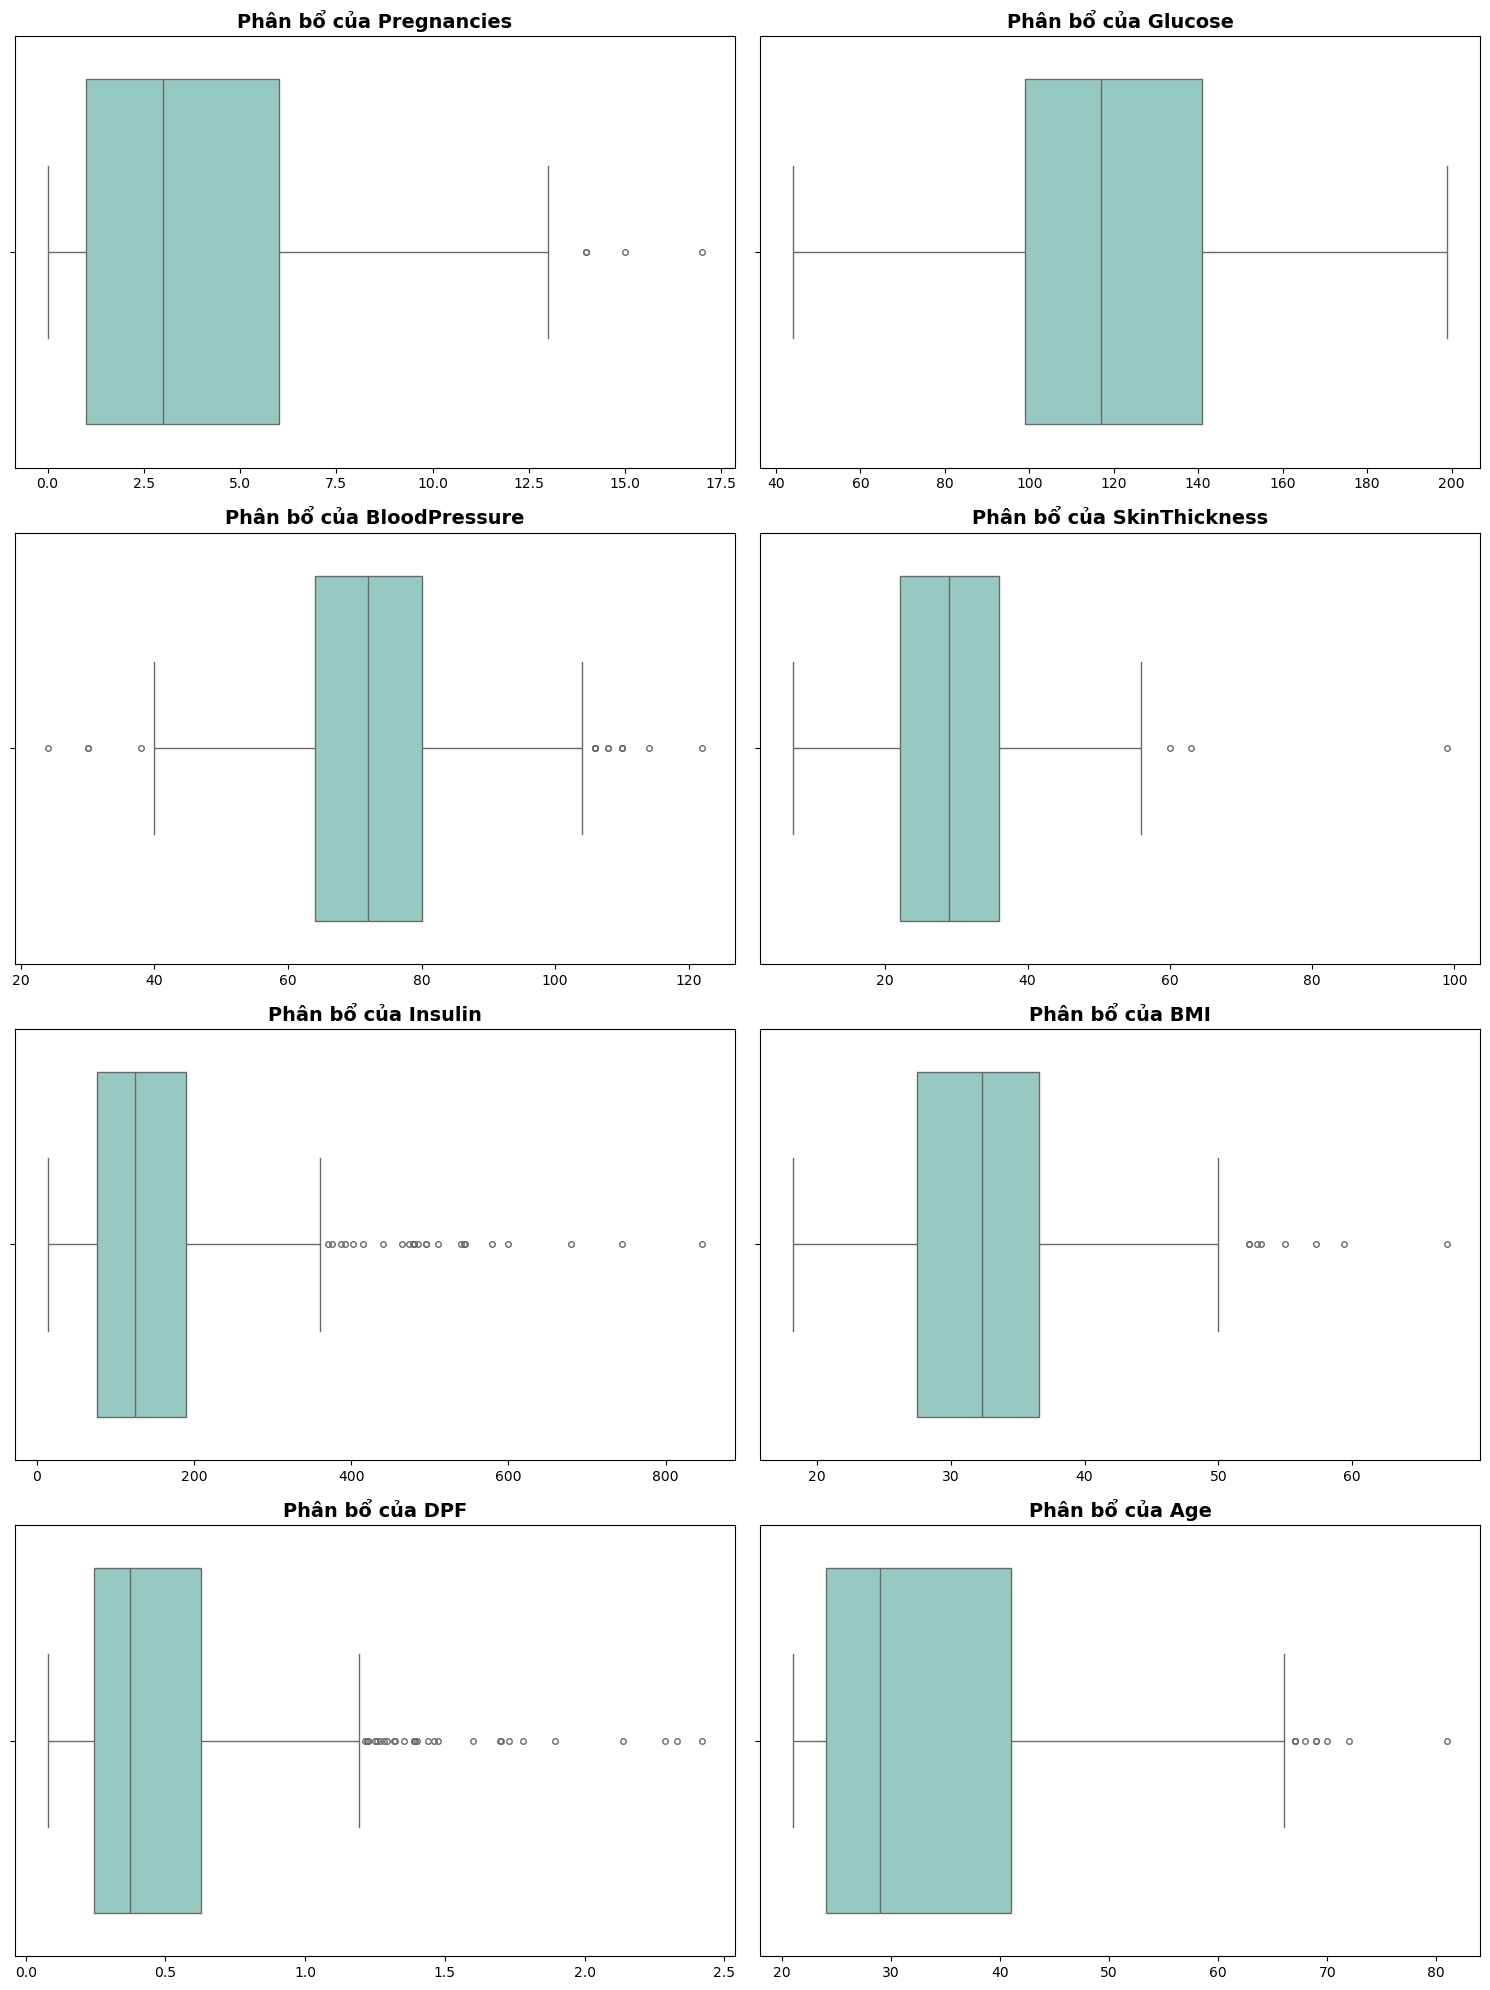

In [76]:

# 1. Thiết lập danh sách các cột cần vẽ
cols_to_plot = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", 
                "Insulin", "BMI", "DPF", "Age"]
# 2. Khởi tạo khung hình (4 hàng, 2 cột)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
axes = axes.flatten() # Chuyển mảng 2 chiều thành 1 chiều để dễ lặp
# 3. Vẽ từng biểu đồ vào các ô tương ứng
for i, col in enumerate(cols_to_plot):
    sns.boxplot(x=df_dataset[col], ax=axes[i], palette="Set3", fliersize=4)
    axes[i].set_title(f"Phân bổ của {col}", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("") # Ẩn tên trục X cho gọn
# 4. Tự động điều chỉnh khoảng cách để không bị đè chữ
plt.tight_layout()
plt.show()

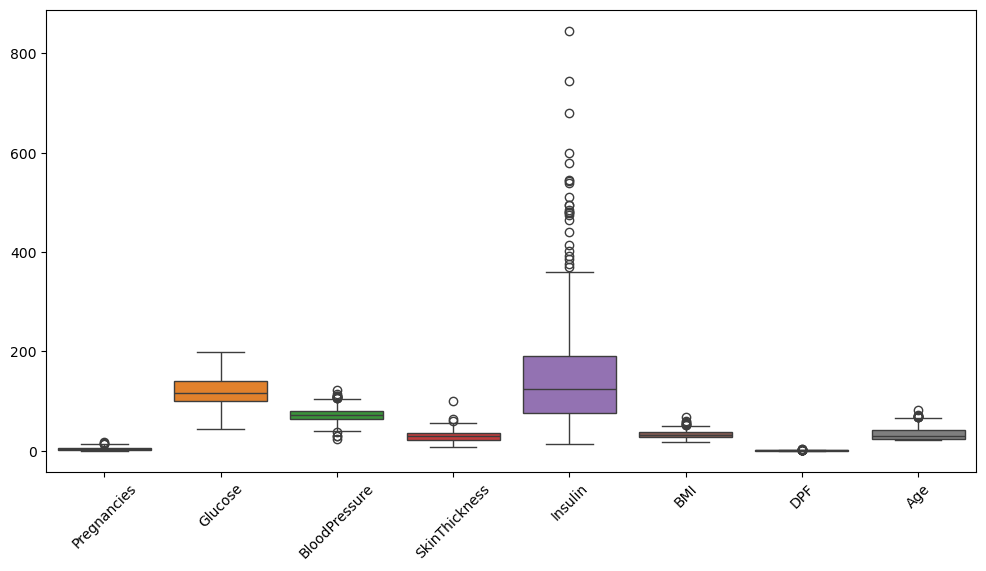

In [77]:
sns.boxplot(data=df_dataset.iloc[:, :-1]) # Loại bỏ cột Outcome cuối cùng
plt.xticks(rotation=45) # Xoay tên các cột để dễ đọc
plt.show()

### b. Biểu đồ tần suất (Histogram)

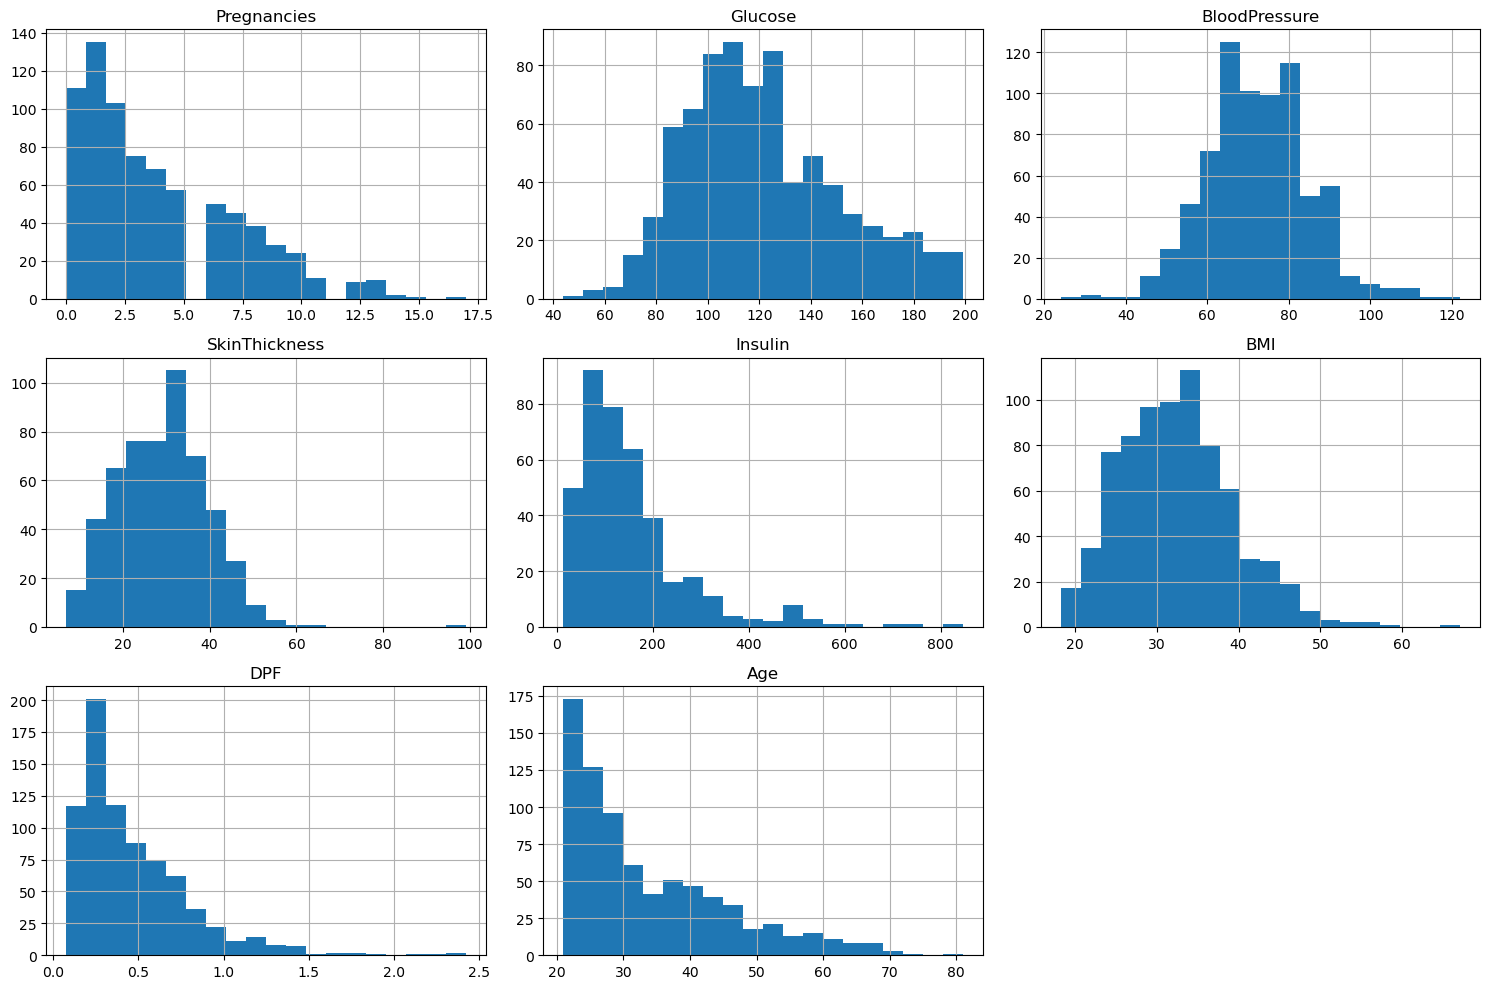

In [78]:
df_dataset.iloc[:, :-1].hist(bins=20, figsize=(15, 10)) 
plt.tight_layout()
plt.show()

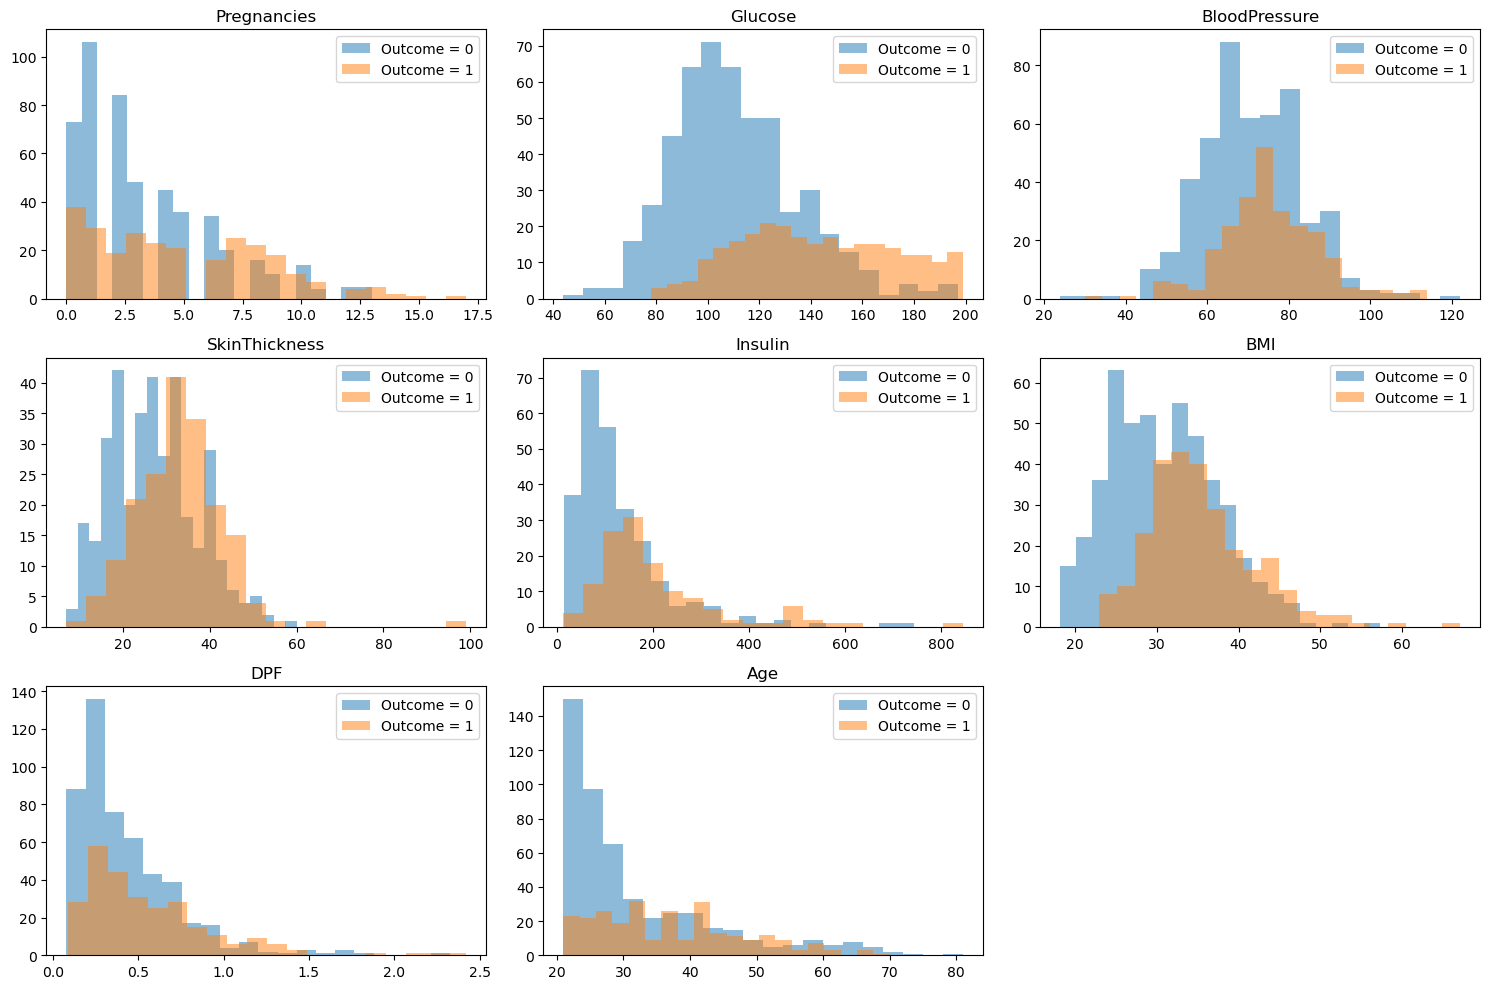

In [79]:
features = df_dataset.columns[:-1]  # tất cả cột trừ Outcome
plt.figure(figsize=(15,10))
for i, col in enumerate(features, 1):
    plt.subplot(3,3,i)
    plt.hist(df_dataset[df_dataset["Outcome"]==0][col], bins=20, alpha=0.5, label="Outcome = 0")
    plt.hist(df_dataset[df_dataset["Outcome"]==1][col], bins=20, alpha=0.5, label="Outcome = 1")
    plt.title(col)
    plt.legend()
plt.tight_layout()
plt.show()

### d. Biểu đồ phân tán

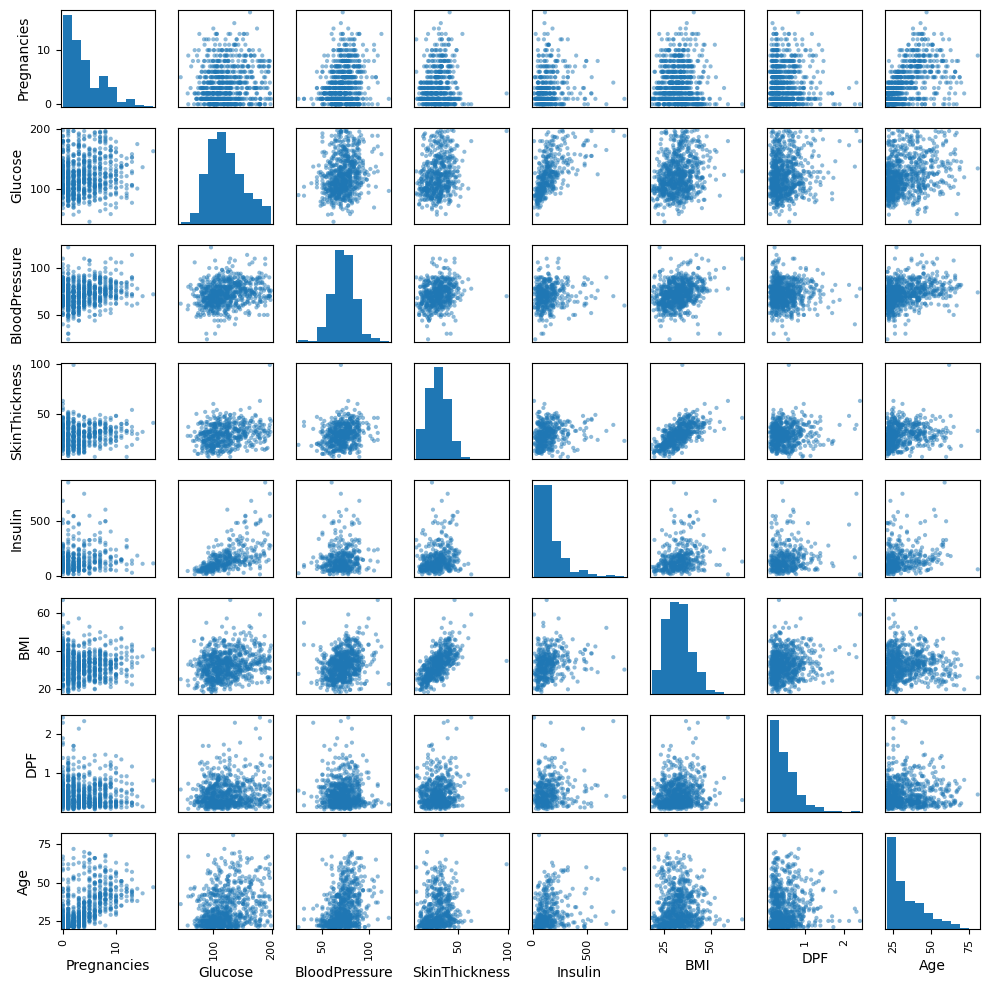

In [80]:
pd.plotting.scatter_matrix(df_dataset.drop(columns=['Outcome']), figsize=(10, 10))
plt.tight_layout()
plt.show()

### Correlation Heatmap

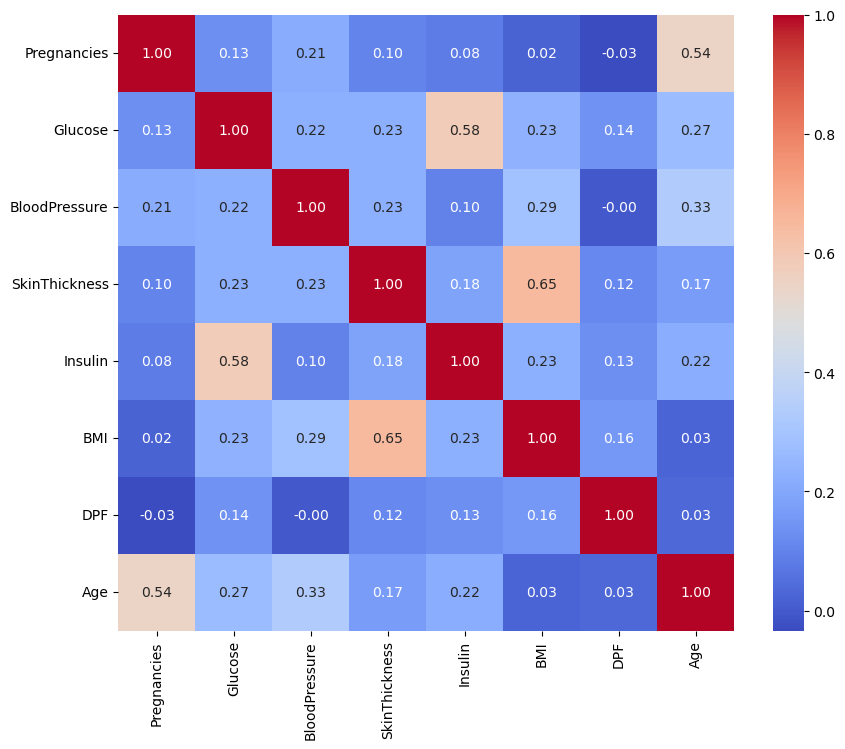

In [81]:
correlations = df_dataset.iloc[:, :-1].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlations, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.gca().set_xticklabels(list(df_dataset.columns[:-1]));
plt.gca().set_yticklabels(list(df_dataset.columns[:-1]));

### Destiny plot

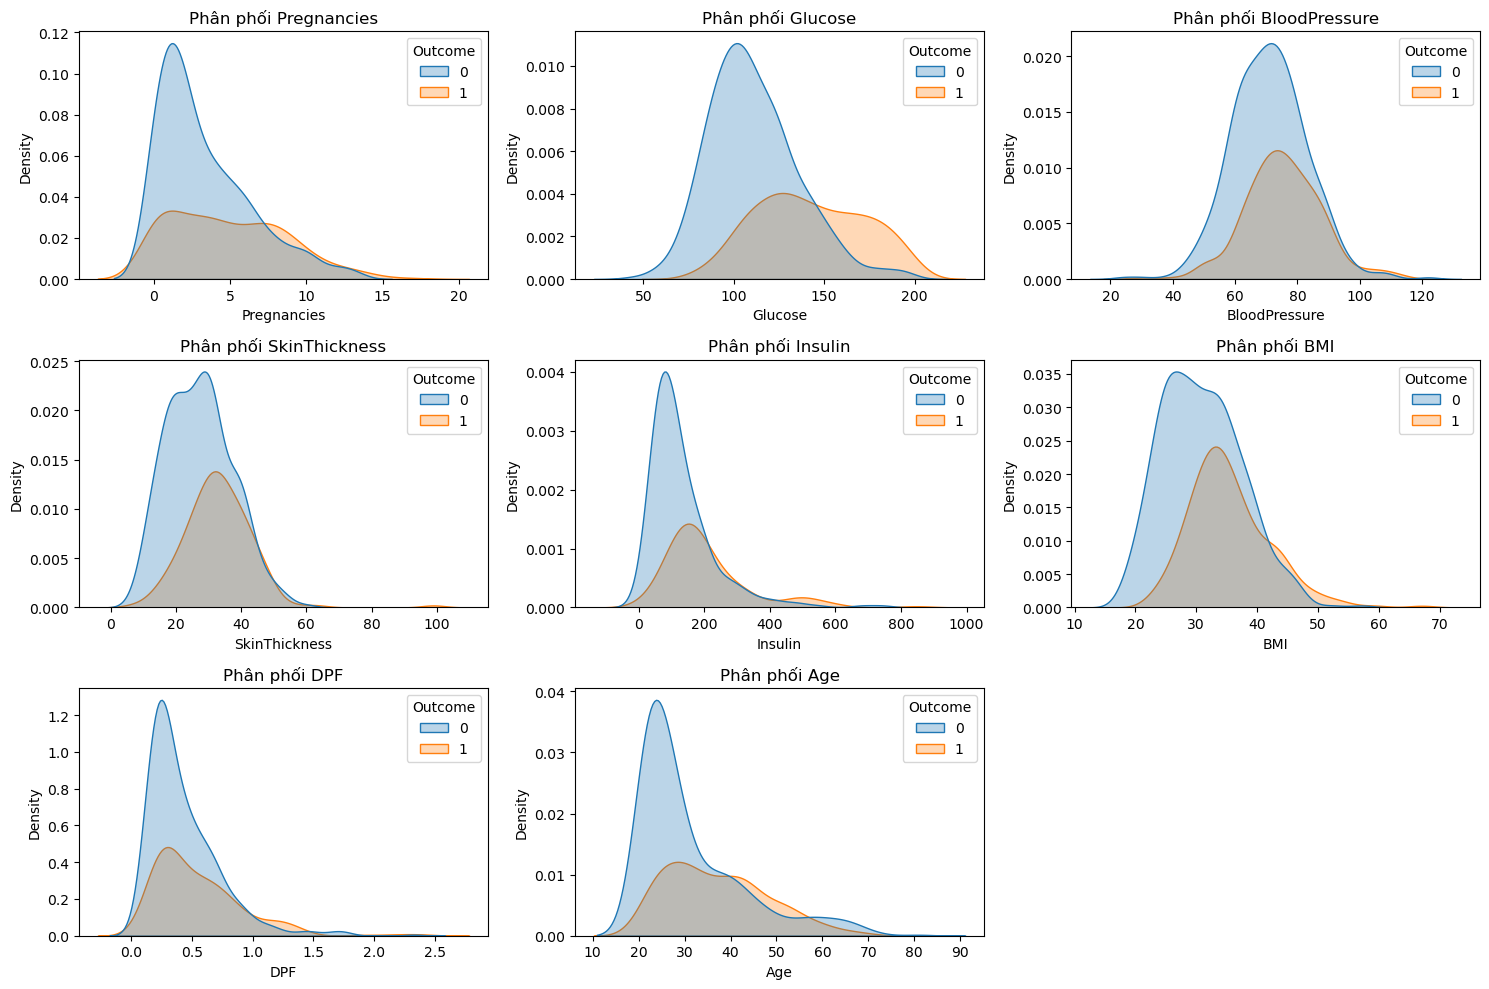

In [82]:
features = df_dataset.columns[:-1]  # tất cả cột trừ Outcome
plt.figure(figsize=(15,10))
for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.kdeplot(data=df_dataset, x=col, hue="Outcome", fill=True, alpha=0.3)
    plt.title(f"Phân phối {col}")
plt.tight_layout()
plt.show()

# Kết thúc